In [19]:
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
from ordered_set import OrderedSet

from StoneSoupID.stonesoupID.types.groundtruth import GroundTruthPath, GroundTruthState
from StoneSoupID.stonesoupID.models.transition.linear import (
    CombinedLinearGaussianTransitionModel,
    ConstantVelocity,
    LinearGaussianTimeInvariantTransitionModel
)
from StoneSoupID.stonesoupID.models.measurement.linear import LinearGaussian
from StoneSoupID.stonesoupID.types.detection import TrueDetection
from StoneSoupID.stonesoupID.types.state import GaussianState
from StoneSoupID.stonesoupID.predictor.kalman import KalmanPredictor
from StoneSoupID.stonesoupID.updater.kalman import KalmanUpdater
from StoneSoupID.stonesoupID.hypothesiser.probability import PDAHypothesiser
from StoneSoupID.stonesoupID.dataassociator.probability import JPDAwithLBP as JPDA
from StoneSoupID.stonesoupID.initiator.simple import MultiMeasurementInitiator
from StoneSoupID.stonesoupID.deleter.time import UpdateTimeDeleter
from StoneSoupID.stonesoupID.tracker.simple import MultiTargetTracker

# ---- Augmented Measurement Model for AR(1) Noise ----
class Augmented2DMeasurement(LinearGaussian):
    def function(self, state_vector, noise=False, **kwargs):
        # Accept both State objects and numpy arrays
        if hasattr(state_vector, 'state_vector'):
            s = np.asarray(state_vector.state_vector).flatten()
        else:
            s = np.asarray(state_vector).flatten()
        vec = np.array([
            s[0] + s[4],
            s[2] + s[5]
        ]).reshape(2, 1)
        if noise is True:
            vec += self.rvs()
        return vec

    def jacobian(self, state_vector, **kwargs):
        H = np.zeros((2, 6))
        H[0, 0] = 1  # x
        H[0, 4] = 1  # n_x
        H[1, 2] = 1  # y
        H[1, 5] = 1  # n_y
        return H

# ---- KF Experiment Function ----
def run_kf_experiment(seed, num_steps, rho, process_noise_var, sigma):
    np.random.seed(seed)
    init_states = [
        [0, 1, 0, 1, 0, 0],
        [20, -1, 10, -1, 0, 0]
    ]
    ar1_model = LinearGaussianTimeInvariantTransitionModel(
        transition_matrix=np.array([[rho]]),
        covariance_matrix=np.array([[sigma**2]])
    )
    transition_model = CombinedLinearGaussianTransitionModel([
        ConstantVelocity(np.sqrt(process_noise_var)),
        ConstantVelocity(np.sqrt(process_noise_var)),
        ar1_model, ar1_model
    ])

    measurement_model = Augmented2DMeasurement(
        ndim_state=6,
        mapping=(0, 2),
        noise_covar=np.zeros((2, 2))
    )
    dt = 0.05
    timesteps = [datetime.now() + timedelta(seconds=k*dt) for k in range(num_steps + 1)]
    truths = OrderedSet()
    truth_paths = []
    for state in init_states:
        truth = GroundTruthPath([GroundTruthState(state, timestamp=timesteps[0])])
        for k in range(1, num_steps + 1):
            next_state = transition_model.function(truth[k-1], noise=True, time_interval=timedelta(seconds=dt))
            truth.append(GroundTruthState(next_state, timestamp=timesteps[k]))
        truths.add(truth)
        truth_paths.append(truth)
    all_measurements = []
    for k in range(num_steps + 1):
        measurement_set = set()
        for idx, truth in enumerate(truth_paths):
            s = truth[k].state_vector.flatten()
            meas_vec = np.array([s[0] + s[4], s[2] + s[5]])
            measurement_set.add(TrueDetection(
                state_vector=meas_vec.reshape(-1, 1),
                groundtruth_path=truth,
                timestamp=timesteps[k],
                measurement_model=measurement_model
            ))
        all_measurements.append(measurement_set)

    predictor = KalmanPredictor(transition_model)
    updater = KalmanUpdater(measurement_model)
    hypothesiser = PDAHypothesiser(
        predictor=predictor,
        updater=updater,
        clutter_spatial_density=1e-12,
        prob_detect=1.0,
        prob_gate=0.999
    )
    data_associator = JPDA(hypothesiser=hypothesiser)
    prior_cov = np.diag([100, 10, 100, 10, 25, 25])
    prior_state = GaussianState(np.array(init_states[0]).reshape(-1, 1), prior_cov, timestamp=timesteps[0])
    deleter = UpdateTimeDeleter(time_since_update=timedelta(seconds=10))
    initiator = MultiMeasurementInitiator(
        prior_state=prior_state,
        deleter=deleter,
        data_associator=data_associator,
        updater=updater,
        measurement_model=measurement_model,
        min_points=1
    )

    detector = iter(list(zip(timesteps, all_measurements)))
    tracker = MultiTargetTracker(
        initiator=initiator,
        deleter=deleter,
        data_associator=data_associator,
        updater=updater,
        detector=detector
    )

    tracks = set()
    for time, curr_tracks in tracker:
        tracks |= curr_tracks
    tracks = {track for track in tracks if len(track) > 3}
    tracks = list(tracks)

    truth_arrays = [np.array([[s.state_vector[0], s.state_vector[2]] for s in truth]) for truth in truth_paths]
    track_arrays = [np.array([[s.state_vector[0], s.state_vector[2]] for s in track]) for track in tracks]

    rmse_time = []
    for t in range(num_steps + 1):
        errors = []
        for truth in truth_arrays:
            min_err = None
            for track in track_arrays:
                if t < track.shape[0]:
                    err = np.linalg.norm(track[t] - truth[t])
                    if (min_err is None) or (err < min_err):
                        min_err = err
            if min_err is not None:
                errors.append(min_err ** 2)
        if errors:
            rmse_t = np.sqrt(np.mean(errors))
            rmse_time.append(rmse_t)
        else:
            rmse_time.append(np.nan)
    overall_rmse = np.nanmean(rmse_time)
    return np.array(rmse_time), overall_rmse

# --- Run 10 seeds and average ---


"""
plt.figure(figsize=(8, 4))
plt.plot(mean_rmse, label="Mean RMSE (10 seeds)")
plt.xlabel("Time Step")
plt.ylabel("RMSE")
plt.title("Averaged RMSE vs Time over 10 seeds")
plt.grid(linestyle=":")
plt.legend()
plt.tight_layout()
plt.show()
"""

"""
def get_rho_plot(seed, num_steps, rho, process_noise_var, sigma):
    rho_values = np.linspace(0.90, 0.999, 16)
    mean_overall_rmses = []
    for rho in rho_values:
        all_rmse = []
        overall_rmse_list = []
        np.random.seed(12345)
        seeds = np.random.randint(0, 1e9, num_seeds)
        for seed in seeds:
            rmse_time, overall_rmse = run_kf_experiment(seed, num_steps, rho, process_noise_var, sigma)
            all_rmse.append(rmse_time)
            overall_rmse_list.append(overall_rmse)
        mean_overall_rmses.append(np.mean(overall_rmse_list))

    plt.figure()
    plt.plot(rho_values, mean_overall_rmses, marker="o")
    plt.xlabel(r"AR(1) $\rho$")
    plt.ylabel("Mean Overall RMSE")
    plt.title("RMSE vs AR(1) Persistence ($\\rho$)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    return mean_overall_rmses

_ = get_rho_plot(seed, num_steps, rho, process_noise_var, sigma)
"""
num_seeds = 1
seeds = np.random.randint(0, 1e9, num_seeds)
num_steps = 200
rho = 0.9999
sigma = 3.0
process_noise_var = 0.02
all_rmse = []
overall_rmse_list = []
for seed in seeds:
    rmse_time, overall_rmse = run_kf_experiment(seed, num_steps, rho, process_noise_var, sigma)
    all_rmse.append(rmse_time)
    overall_rmse_list.append(overall_rmse)

all_rmse = np.vstack(all_rmse)
mean_rmse = np.nanmean(all_rmse, axis=0)
print(f"Average of Mean Overall RMSEs: {np.mean(overall_rmse_list):.3f}")


/Users/priyankbehera/Desktop/ID_JPDAF/StoneSoupID/stonesoupID/dataassociator/probability.py:307: RuntimeWarning: divide by zero encountered in divide
  mu = likelihood_matrix[:, 1:] / s
/Users/priyankbehera/Desktop/ID_JPDAF/StoneSoupID/stonesoupID/dataassociator/probability.py:314: RuntimeWarning: invalid value encountered in subtract
  nu = 1 / (1 + np.sum(mu, axis=0, keepdims=True) - mu)
/Users/priyankbehera/Desktop/ID_JPDAF/StoneSoupID/stonesoupID/dataassociator/probability.py:317: RuntimeWarning: divide by zero encountered in log10
  d = np.max(np.abs(np.log10(nu / nu_tilde)))


Average of Mean Overall RMSEs: 6.528


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import PchipInterpolator
import scienceplots

plt.style.use(['science', 'ieee'])

# Set global font sizes
plt.rcParams.update({
    'font.size': 18,        # General font size
    'axes.titlesize': 22,   # Axes title font size
    'axes.labelsize': 20,   # Axes label font size
    'legend.fontsize': 18,  # Legend font size
    'xtick.labelsize': 16,  # X-tick font size
    'ytick.labelsize': 16   # Y-tick font size
})

rhos = np.array([0, 0.05, 0.1, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 
                 0.50, 0.55, 0.60, 0.65, 0.70, 0.75, 0.80, 0.85, 0.90, 0.91, 
                 0.92, 0.93, 0.94, 0.95, 0.96, 0.97, 0.98, 0.99, 0.999, 0.9999])
means_id = np.array([3.702, 3.986, 4.012, 4.038, 4.082, 4.118, 4.226, 4.386, 4.334, 4.435, 
                     4.673, 4.714, 4.846, 4.947, 5.008, 5.062, 5.104, 5.115, 5.892, 6.076,
                     6.083, 6.104, 6.133, 6.159, 6.181, 6.193, 6.212 , 6.222, 6.260, 6.315])
means = np.array([3.703, 4.500, 4.552, 5.706, 5.812, 6.032, 6.320, 6.428, 6.723, 6.943, 
                7.115, 8.283, 8.324, 8.402, 8.465, 8.594, 9.369, 9.671, 10.080, 10.808, 
                11.181, 11.482, 11.700, 12.031, 14.170, 15.953, 16.269, 17.037, 19.073, 21.282])

rhos_smooth = np.linspace(rhos.min(), rhos.max(), 500)
interp_means_id = PchipInterpolator(rhos, means_id)
interp_means = PchipInterpolator(rhos, means)

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(rhos_smooth, interp_means_id(rhos_smooth), color='#1f77b4', linestyle='-', linewidth=2, label='ID-JPDAF')
ax.plot(rhos_smooth, interp_means(rhos_smooth), color='#8B0000', linestyle='-', linewidth=2, alpha=0.6, label='JPDAF')

ax.set_xlabel(r'Coloredness Factor $\rho$', fontsize=20)
ax.set_ylabel('RMSE, m', fontsize=20)
ax.set_title(r'RMSE vs. $\rho$', fontsize=22)

ax.minorticks_on()
ax.grid(True, which='major', linestyle=':', linewidth=1, alpha=0.8)
ax.grid(True, which='minor', linestyle=':', linewidth=0.7, alpha=0.5)

ax.legend(fontsize=18)
plt.tight_layout()
plt.show()


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
from ordered_set import OrderedSet

from StoneSoupID.stonesoupID.types.groundtruth import GroundTruthPath, GroundTruthState
from StoneSoupID.stonesoupID.models.transition.linear import (
    CombinedLinearGaussianTransitionModel,
    ConstantVelocity,
    LinearGaussianTimeInvariantTransitionModel
)
from StoneSoupID.stonesoupID.models.measurement.linear import LinearGaussian
from StoneSoupID.stonesoupID.types.detection import TrueDetection
from StoneSoupID.stonesoupID.types.state import GaussianState
from StoneSoupID.stonesoupID.predictor.kalman import KalmanPredictor
from StoneSoupID.stonesoupID.updater.kalman import KalmanUpdater
from StoneSoupID.stonesoupID.hypothesiser.probability import PDAHypothesiser
from StoneSoupID.stonesoupID.dataassociator.probability import JPDAwithLBP as JPDA
from StoneSoupID.stonesoupID.initiator.simple import MultiMeasurementInitiator
from StoneSoupID.stonesoupID.deleter.time import UpdateTimeDeleter
from StoneSoupID.stonesoupID.tracker.simple import MultiTargetTracker

# ---- Augmented Measurement Model for AR(1) Noise ----
class Augmented2DMeasurement(LinearGaussian):
    def function(self, state_vector, noise=False, **kwargs):
        # Accept both State objects and numpy arrays
        if hasattr(state_vector, 'state_vector'):
            s = np.asarray(state_vector.state_vector).flatten()
        else:
            s = np.asarray(state_vector).flatten()
        vec = np.array([
            s[0] + s[4],
            s[2] + s[5]
        ]).reshape(2, 1)
        if noise is True:
            vec += self.rvs()
        return vec

    def jacobian(self, state_vector, **kwargs):
        H = np.zeros((2, 6))
        H[0, 0] = 1  # x
        H[0, 4] = 1  # n_x
        H[1, 2] = 1  # y
        H[1, 5] = 1  # n_y
        return H

def run_kf_experiment_mismatch(seed, num_steps,
                               rho_true, sigma_true,      # Used for data generation
                               rho_filter, sigma_filter,  # Used for filtering
                               process_noise_var):
    np.random.seed(seed)
    init_states = [
        [0, 1, 0, 1, 0, 0],
        [20, -1, 10, -1, 0, 0]
    ]
    # 1. Truth uses "true" parameters
    ar1_model_truth = LinearGaussianTimeInvariantTransitionModel(
        transition_matrix=np.array([[rho_true]]),
        covariance_matrix=np.array([[sigma_true**2]])
    )
    transition_model_truth = CombinedLinearGaussianTransitionModel([
        ConstantVelocity(np.sqrt(process_noise_var)),
        ConstantVelocity(np.sqrt(process_noise_var)),
        ar1_model_truth, ar1_model_truth
    ])
    # 2. Filter uses "mismatched" parameters
    ar1_model_filter = LinearGaussianTimeInvariantTransitionModel(
        transition_matrix=np.array([[rho_filter]]),
        covariance_matrix=np.array([[sigma_filter**2]])
    )
    transition_model_filter = CombinedLinearGaussianTransitionModel([
        ConstantVelocity(np.sqrt(process_noise_var)),
        ConstantVelocity(np.sqrt(process_noise_var)),
        ar1_model_filter, ar1_model_filter
    ])

    measurement_model = Augmented2DMeasurement(
        ndim_state=6,
        mapping=(0, 2),
        noise_covar=np.zeros((2, 2))
    )
    dt = 0.1
    timesteps = [datetime.now() + timedelta(seconds=k*dt) for k in range(num_steps + 1)]
    # --- Generate truth and measurements with TRUE model ---
    truths = OrderedSet()
    truth_paths = []
    for state in init_states:
        truth = GroundTruthPath([GroundTruthState(state, timestamp=timesteps[0])])
        for k in range(1, num_steps + 1):
            next_state = transition_model_truth.function(truth[k-1], noise=True, time_interval=timedelta(seconds=dt))
            truth.append(GroundTruthState(next_state, timestamp=timesteps[k]))
        truths.add(truth)
        truth_paths.append(truth)
    all_measurements = []
    for k in range(num_steps + 1):
        measurement_set = set()
        for idx, truth in enumerate(truth_paths):
            s = truth[k].state_vector.flatten()
            meas_vec = np.array([s[0] + s[4], s[2] + s[5]])
            measurement_set.add(TrueDetection(
                state_vector=meas_vec.reshape(-1, 1),
                groundtruth_path=truth,
                timestamp=timesteps[k],
                measurement_model=measurement_model
            ))
        all_measurements.append(measurement_set)

    # --- Filtering using MISMATCHED model ---
    predictor = KalmanPredictor(transition_model_filter)
    updater = KalmanUpdater(measurement_model)
    hypothesiser = PDAHypothesiser(
        predictor=predictor,
        updater=updater,
        clutter_spatial_density=1e-12,
        prob_detect=1.0,
        prob_gate=0.999
    )
    data_associator = JPDA(hypothesiser=hypothesiser)
    prior_cov = np.diag([100, 10, 100, 10, 25, 25])
    prior_state = GaussianState(np.array(init_states[0]).reshape(-1, 1), prior_cov, timestamp=timesteps[0])
    deleter = UpdateTimeDeleter(time_since_update=timedelta(seconds=10))
    initiator = MultiMeasurementInitiator(
        prior_state=prior_state,
        deleter=deleter,
        data_associator=data_associator,
        updater=updater,
        measurement_model=measurement_model,
        min_points=1
    )

    detector = iter(list(zip(timesteps, all_measurements)))
    tracker = MultiTargetTracker(
        initiator=initiator,
        deleter=deleter,
        data_associator=data_associator,
        updater=updater,
        detector=detector
    )

    tracks = set()
    for time, curr_tracks in tracker:
        tracks |= curr_tracks
    tracks = {track for track in tracks if len(track) > 3}
    tracks = list(tracks)

    truth_arrays = [np.array([[s.state_vector[0], s.state_vector[2]] for s in truth]) for truth in truth_paths]
    track_arrays = [np.array([[s.state_vector[0], s.state_vector[2]] for s in track]) for track in tracks]

    rmse_time = []
    for t in range(num_steps + 1):
        errors = []
        for truth in truth_arrays:
            min_err = None
            for track in track_arrays:
                if t < track.shape[0]:
                    err = np.linalg.norm(track[t] - truth[t])
                    if (min_err is None) or (err < min_err):
                        min_err = err
            if min_err is not None:
                errors.append(min_err ** 2)
        if errors:
            rmse_t = np.sqrt(np.mean(errors))
            rmse_time.append(rmse_t)
        else:
            rmse_time.append(np.nan)
    overall_rmse = np.nanmean(rmse_time)
    return np.array(rmse_time), overall_rmse

num_seeds = 2
num_steps = 200

# "Truth" parameters (used in data generation)
rho_true = 0.9
sigma_true = 0.5

# "Filter" parameters (used in the filter model -- mismatch here!)
rho_filter = 0.95
sigma_filter = 1.5

process_noise_var = 0.02

all_rmse = []
overall_rmse_list = []
for seed in range(num_seeds):
    rmse_time, overall_rmse = run_kf_experiment_mismatch(
        seed, num_steps, rho_true, sigma_true, rho_filter, sigma_filter, process_noise_var)
    all_rmse.append(rmse_time)
    overall_rmse_list.append(overall_rmse)

all_rmse = np.vstack(all_rmse)
mean_rmse = np.nanmean(all_rmse, axis=0)

"""
plt.figure(figsize=(8, 4))
plt.plot(mean_rmse, label="Mean RMSE (mismatched params)")
plt.xlabel("Time Step")
plt.ylabel("RMSE")
plt.title("Averaged RMSE with Parameter Mismatch")
plt.grid(linestyle=":")
plt.legend()
plt.tight_layout()
plt.show()
"""

print(f"Average of Mean Overall RMSEs: {np.mean(overall_rmse_list):.3f}")
print(mean_rmse)


/Users/priyankbehera/Desktop/ID_JPDAF/StoneSoupID/stonesoupID/dataassociator/probability.py:307: RuntimeWarning: divide by zero encountered in divide
  mu = likelihood_matrix[:, 1:] / s
/Users/priyankbehera/Desktop/ID_JPDAF/StoneSoupID/stonesoupID/dataassociator/probability.py:314: RuntimeWarning: invalid value encountered in subtract
  nu = 1 / (1 + np.sum(mu, axis=0, keepdims=True) - mu)
/Users/priyankbehera/Desktop/ID_JPDAF/StoneSoupID/stonesoupID/dataassociator/probability.py:317: RuntimeWarning: divide by zero encountered in log10
  d = np.max(np.abs(np.log10(nu / nu_tilde)))


Average of Mean Overall RMSEs: 4.042
[ 0.          0.42449498  0.53633136  0.63648624  0.86021831  0.95019985
  1.02385814  0.92805138  0.9381037   1.0502706   1.21817743  1.34710262
  1.33690519  1.19462139  1.17809451  1.19150758  1.34631335  1.41167853
  1.61292111  1.87605506  2.08339537  2.14734708  2.09519891  2.0974134
  2.11595338  2.02433122  1.93723595  1.64438033  1.44450484  1.36083487
  1.32575754  1.22740313  1.2693745   1.42614788  1.42517936  1.46619445
  1.55404475  1.65937989  2.03836795  2.16324764  2.28794289  2.38440869
  2.37691691  2.40244444  2.45672601  2.46509541  2.50808305  2.57188183
  2.56998257  2.58735527  2.6216171   2.66737321  2.6043694   2.59712647
  2.59638695  2.60526215  2.89418811  2.9013463   2.91565557  2.8604869
  2.79961798  2.7526256   2.66314974  2.55116425  2.45829921  2.39592736
  2.6566236   2.68655189  2.24302789  2.09970656  2.0053369   1.93643684
  1.98750986  2.06145879  2.09608695  2.17314366  2.31377897  2.51022462
  2.73304839  2.

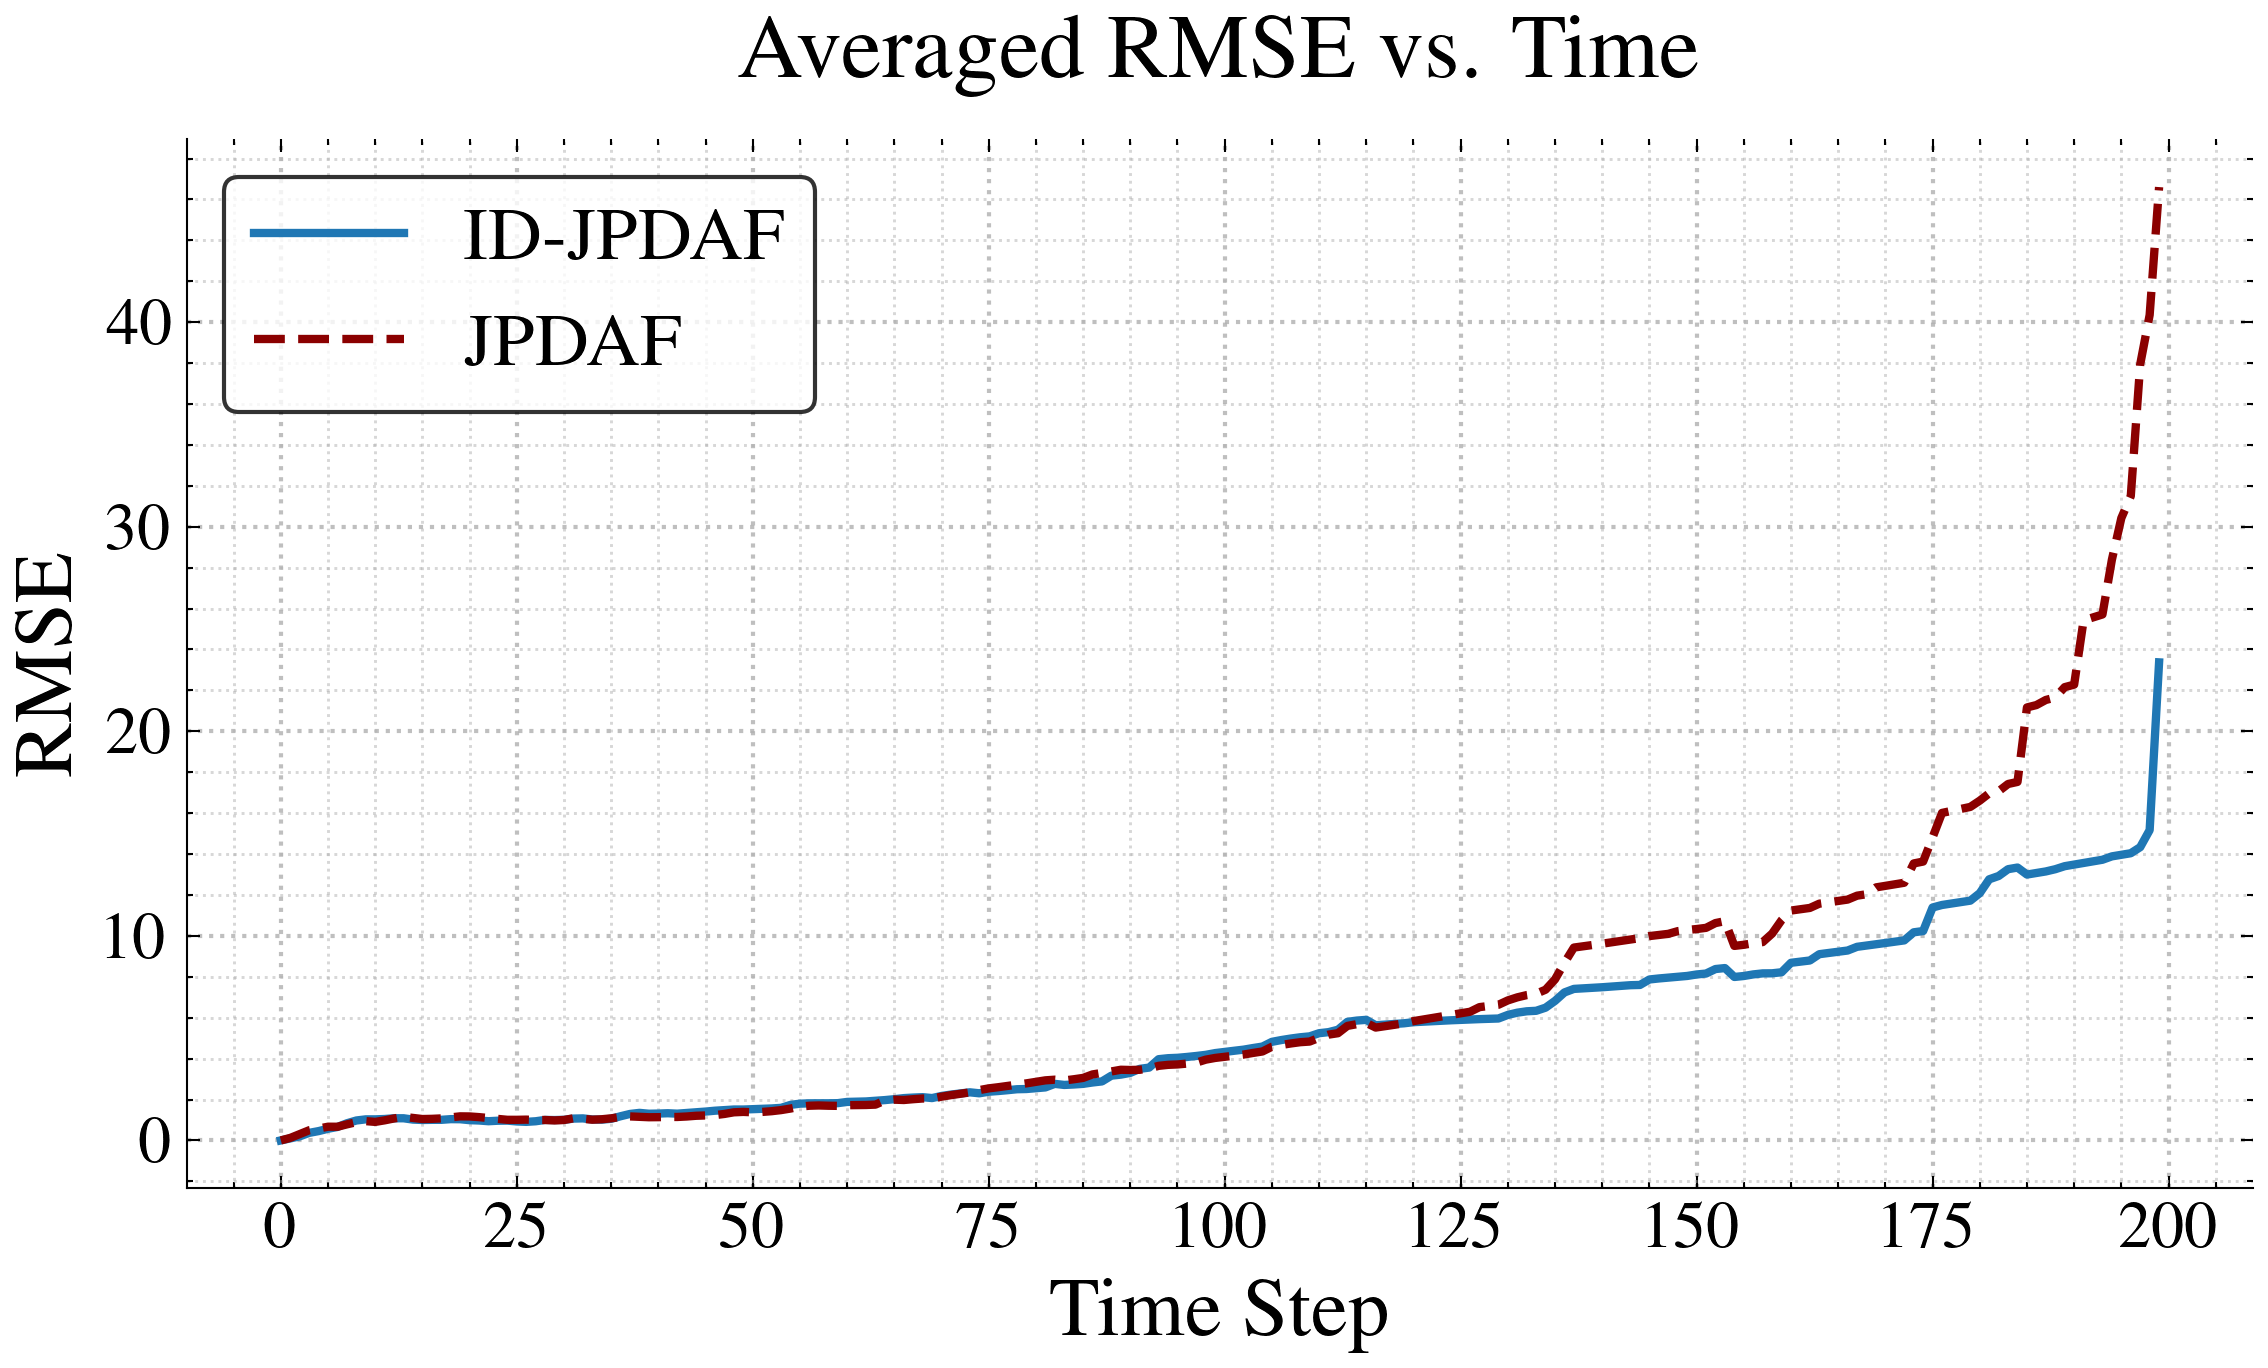

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scienceplots

plt.style.use(['science', 'ieee'])

plt.rcParams.update({
    'font.size': 18,
    'axes.titlesize': 22,
    'axes.labelsize': 20,
    'legend.fontsize': 18,
    'xtick.labelsize': 16,
    'ytick.labelsize': 16,
    'font.weight': 'bold',
    'axes.labelweight': 'bold'
})

mean_rmse_id = np.array([
    0., 0.10030837, 0.19773048, 0.36877441, 0.45507743, 0.56998847,
    0.65735703, 0.83731771, 0.97389975, 1.02967839, 1.02956408, 1.04657417,
    1.08224617, 1.08245792, 1.01771162, 0.99868177, 1.00572114, 1.00633228,
    1.03958249, 1.03534598, 0.98976926, 0.97334527, 0.9384283, 0.96226364,
    0.96790668, 0.9269063, 0.90707222, 0.93637079, 1.00094201, 0.99489838,
    1.00603088, 1.06654022, 1.07695609, 1.02410495, 1.0142872, 1.05683013,
    1.1820507, 1.29386189, 1.34661053, 1.30417041, 1.31239921, 1.32879786,
    1.30756595, 1.3420364, 1.37237826, 1.41008201, 1.45244683, 1.48130406,
    1.51033787, 1.51009119, 1.52813728, 1.54696859, 1.56217315, 1.59250691,
    1.7368101, 1.7964083, 1.8134142, 1.81190755, 1.81470987, 1.82135075,
    1.88181081, 1.890892, 1.90528562, 1.93782862, 1.9711854, 2.01545992,
    2.06782291, 2.09479535, 2.11362241, 2.07017343, 2.1732819, 2.24097832,
    2.29681748, 2.35077852, 2.30352077, 2.38047082, 2.41391271, 2.45521123,
    2.50210441, 2.5127028, 2.55240977, 2.5909075, 2.76446668, 2.71191766,
    2.73335647, 2.76466189, 2.83177944, 2.88504396, 3.16635434, 3.21591519,
    3.30136644, 3.4982856, 3.56025973, 3.97051144, 4.01905406, 4.03843285,
    4.07988631, 4.12825117, 4.18372151, 4.26938751, 4.32721657, 4.38246317,
    4.43691239, 4.5158229, 4.58787924, 4.81856808, 4.90645617, 4.9800108,
    5.04198278, 5.08665738, 5.24084215, 5.29307492, 5.41013502, 5.79618275,
    5.85892718, 5.89417868, 5.63044222, 5.66111056, 5.69447472, 5.72506809,
    5.77997295, 5.80458283, 5.83067445, 5.85447994, 5.87333211, 5.89355549,
    5.91635255, 5.92949237, 5.94351088, 5.95956739, 6.13450745, 6.24438328,
    6.31207705, 6.33632368, 6.49009401, 6.82130343, 7.23430996, 7.40722274,
    7.43270485, 7.4593839, 7.48827026, 7.52208959, 7.55335716, 7.58814875,
    7.60007317, 7.86793375, 7.91739399, 7.95690141, 7.99768705, 8.03960869,
    8.11234819, 8.15709661, 8.37778438, 8.42512053, 7.99032242, 8.03735647,
    8.11524053, 8.16570122, 8.16978096, 8.22025709, 8.68377858, 8.74038714,
    8.79575209, 9.10417631, 9.16504841, 9.22557836, 9.28316007, 9.46388502,
    9.52476728, 9.58709685, 9.65087516, 9.71631572, 9.7783894, 10.17312503,
    10.23525249, 11.38676674, 11.50991686, 11.57898483, 11.6489108, 11.72134637,
    12.08679763, 12.76493699, 12.92669165, 13.25934366, 13.33955866, 12.99702375,
    13.07307984, 13.14911098, 13.25798069, 13.4060561, 13.48359875, 13.5617315,
    13.64096427, 13.72097692, 13.88596807, 13.96221208, 14.03925294, 14.33661397,
    15.17056626, 23.37039648
])

mean_rmse = np.array([
    0., 0.12240372, 0.30887679, 0.49620868, 0.58029591, 0.6699887,
    0.66843033, 0.7842246, 0.89121372, 0.94242931, 0.90491446, 0.98147262,
    1.07347765, 1.1523695, 1.09678411, 1.04528115, 1.05474467, 1.07591302,
    1.12405797, 1.17640985, 1.1716033, 1.13819287, 1.09645312, 1.05847386,
    1.00777438, 1.00696414, 1.0160707, 1.00031773, 0.99816832, 0.97683924,
    0.99856229, 1.08162037, 1.05599483, 1.01279888, 1.03445809, 1.079304,
    1.1480244, 1.17306866, 1.15472689, 1.13253528, 1.13614926, 1.14524921,
    1.14607536, 1.16871028, 1.2042909, 1.21798766, 1.23660338, 1.29397645,
    1.37360972, 1.39370186, 1.37446993, 1.39283003, 1.42822036, 1.48168555,
    1.55750932, 1.64887032, 1.69532901, 1.70870361, 1.6953522, 1.68832642,
    1.72068683, 1.72759718, 1.73145261, 1.74920917, 1.95176711, 1.99193439,
    1.97501855, 2.01500073, 2.04874502, 2.04849382, 2.13891337, 2.21384332,
    2.28183427, 2.34664875, 2.45973018, 2.54390067, 2.60074201, 2.66408291,
    2.72879362, 2.78943505, 2.86024882, 2.9365186, 2.96886956, 2.93037827,
    2.98904167, 3.05566028, 3.22600165, 3.2964067, 3.3722838, 3.45442087,
    3.4430911, 3.45328411, 3.51510003, 3.64581491, 3.69405245, 3.71347188,
    3.75532942, 3.80451107, 3.94846353, 4.03233059, 4.08887104, 4.14313762,
    4.19717626, 4.27599312, 4.34777287, 4.57779463, 4.66521782, 4.73887329,
    4.80106501, 4.83242882, 5.01402467, 5.17079184, 5.24058065, 5.59795229,
    5.68123309, 5.74548961, 5.51687449, 5.58356183, 5.65329308, 5.72501211,
    5.83221601, 5.90926303, 5.98815301, 6.06599993, 6.13868004, 6.21304796,
    6.28964692, 6.51637562, 6.5734097, 6.63009615, 6.84443365, 6.99359091,
    7.10384182, 7.17126615, 7.36836864, 7.87452895, 8.68208883, 9.42850077,
    9.49052007, 9.55312886, 9.61739678, 9.68679866, 9.75293307, 9.82155137,
    9.88936893, 9.9891063, 10.04356776, 10.09796206, 10.22984793, 10.28739844,
    10.33386392, 10.39155283, 10.6252412, 10.71893172, 9.50946583, 9.56351107,
    9.64112084, 9.69479036, 10.109245, 10.76555231, 11.23744474, 11.30137154,
    11.36499076, 11.5733542, 11.63944428, 11.70575321, 11.77345925, 11.96411228,
    12.0344182, 12.36907224, 12.44351778, 12.51916795, 12.59593936, 13.5402728,
    13.63210576, 14.81038046, 16.01030244, 16.10718682, 16.2045684, 16.30337943,
    16.61001758, 16.96769698, 17.06894496, 17.42430359, 17.52563951, 21.16632601,
    21.28270796, 21.53257319, 21.65281352, 22.15875194, 22.28165765, 25.4231382,
    25.56707945, 25.71229555, 28.38856814, 30.42488778, 31.49604051, 37.94114114,
    40.35304224, 46.6054659
])

time_steps = np.arange(len(mean_rmse_id))

fig, ax = plt.subplots(figsize=(8, 5), dpi=300)

ax.plot(time_steps, mean_rmse_id, label="ID-JPDAF", color='#1f77b4', linewidth=2)
ax.plot(time_steps, mean_rmse, label="JPDAF", color='#8B0000', linewidth=2)

ax.set_xlabel("Time Step", fontsize=20, fontweight='bold')
ax.set_ylabel("RMSE", fontsize=20, fontweight='bold')
ax.set_title("Averaged RMSE vs. Time", fontsize=22, fontweight='bold', pad=15)

ax.minorticks_on()
ax.grid(True, which='major', linestyle=':', linewidth=1, alpha=0.8)
ax.grid(True, which='minor', linestyle=':', linewidth=0.7, alpha=0.5)

ax.legend(fontsize=18, frameon=True, loc='upper left', edgecolor='black', facecolor='white')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='both', which='major', labelsize=16)

plt.tight_layout()
plt.show()


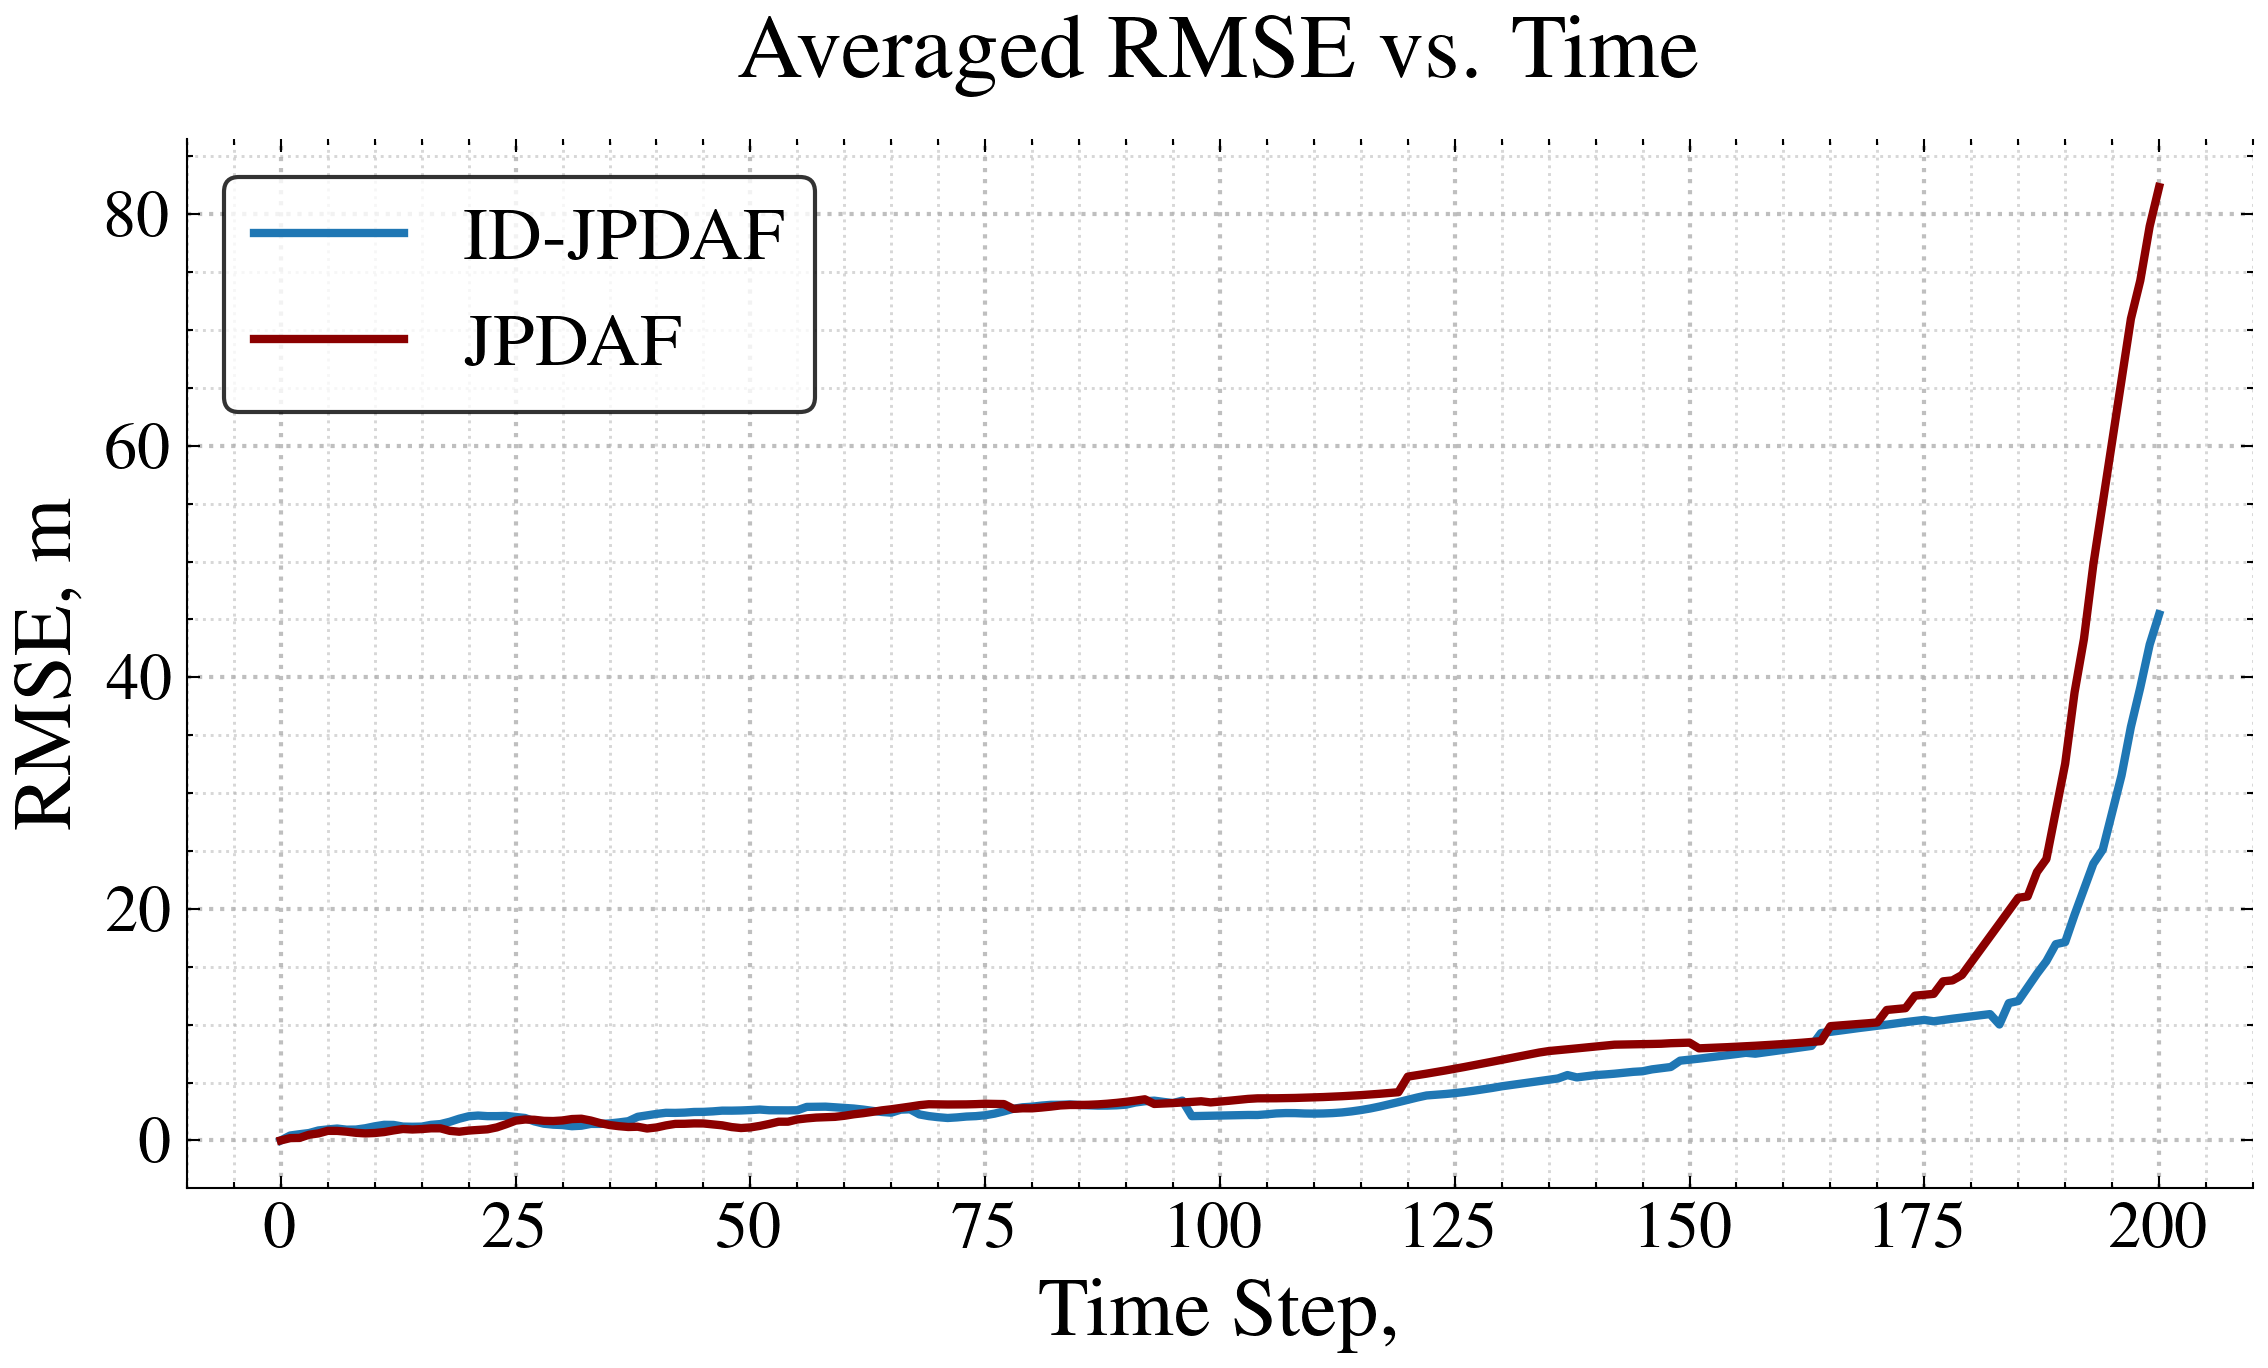

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import scienceplots

plt.style.use(['science', 'ieee'])

plt.rcParams.update({
    'font.size': 18,
    'axes.titlesize': 22,
    'axes.labelsize': 20,
    'legend.fontsize': 18,
    'xtick.labelsize': 16,
    'ytick.labelsize': 16,
    'font.weight': 'bold',
    'axes.labelweight': 'bold'
})

mean_rmse = np.array([
    0., 0.19899322, 0.21604936, 0.49055891, 0.60394817, 0.82580043,
    0.82147639, 0.75506719, 0.65650287, 0.60530505, 0.639809, 0.72112183,
    0.86406836, 0.98649061, 0.94358079, 0.97945002, 1.04435003, 1.04359701,
    0.8247889, 0.750705, 0.8505157, 0.90582931, 0.95788706, 1.12436465,
    1.40057203, 1.70725914, 1.80523236, 1.78194077, 1.69193761, 1.67417057,
    1.72385767, 1.84536379, 1.87432908, 1.71824329, 1.49623935, 1.32887564,
    1.22820075, 1.15769868, 1.18099595, 1.02769774, 1.11894068, 1.29656213,
    1.42822362, 1.4355723, 1.4683378, 1.46417662, 1.38030446, 1.3027732,
    1.15138456, 1.06842208, 1.12196223, 1.2528241, 1.42111413, 1.61420067,
    1.61563711, 1.81010251, 1.90255773, 1.97302483, 2.00470715, 2.0352523,
    2.12616048, 2.25560439, 2.35061914, 2.46811594, 2.5956887, 2.69117696,
    2.80064031, 2.91948743, 3.04468305, 3.12392224, 3.10884097, 3.10225712,
    3.10307332, 3.11181397, 3.13276273, 3.16527925, 3.14770368, 3.13819125,
    2.72648868, 2.77497165, 2.76996796, 2.838164, 2.92072188, 3.01861321,
    3.05946544, 3.0612806, 3.0774561, 3.11336062, 3.17019463, 3.24308774,
    3.33252524, 3.43609407, 3.55198474, 3.1489406, 3.18291927, 3.22592973,
    3.27341929, 3.32524278, 3.3825439, 3.28141085, 3.35186376, 3.42602047,
    3.50400852, 3.58688637, 3.63375706, 3.6339521, 3.64036296, 3.65151762,
    3.66781979, 3.69041554, 3.7160037, 3.74473193, 3.77877372, 3.81780363,
    3.8623369, 3.91067158, 3.96532575, 4.02677268, 4.09415999, 4.16314732,
    5.50994451, 5.63731604, 5.76715381, 5.9022339, 6.04227675, 6.18739325,
    6.33670287, 6.49016615, 6.64611908, 6.80238023, 6.96141543, 7.1224033,
    7.2789635, 7.43596635, 7.59326747, 7.7174188, 7.79204106, 7.87008551,
    7.94994094, 8.03000046, 8.11126567, 8.19466535, 8.26950649, 8.28323945,
    8.29661704, 8.31265626, 8.33107945, 8.35018484, 8.3962931, 8.41860372,
    8.44458748, 7.95322816, 7.98383594, 8.01797813, 8.05337628, 8.09273691,
    8.13387426, 8.17662335, 8.22261254, 8.27245073, 8.32351269, 8.37858103,
    8.44056997, 8.50553281, 8.57478661, 9.87025609, 9.93040908, 9.99129693,
    10.05391634, 10.11992928, 10.19182145, 11.26693987, 11.34417263, 11.42252162,
    12.50125412, 12.57978207, 12.65801995, 13.74028666, 13.82413179, 14.28186605,
    15.39005025, 16.49889081, 17.60903638, 18.72458791, 19.84202149, 20.9566253,
    21.07219535, 23.18809559, 24.30653894, 28.42522011, 32.54340755, 38.69639229,
    43.31927854, 49.75382224, 55.05970796, 60.36669738, 65.67178106, 70.97674929,
    74.28270882, 78.96930299, 82.3476564
])

mean_rmse_id = np.array([
    0., 0.42449498, 0.53633136, 0.63648624, 0.86021831, 0.95019985,
    1.02385814, 0.92805138, 0.9381037, 1.0502706, 1.21817743, 1.34710262,
    1.33690519, 1.19462139, 1.17809451, 1.19150758, 1.34631335, 1.41167853,
    1.61292111, 1.87605506, 2.08339537, 2.14734708, 2.09519891, 2.0974134,
    2.11595338, 2.02433122, 1.93723595, 1.64438033, 1.44450484, 1.36083487,
    1.32575754, 1.22740313, 1.2693745, 1.42614788, 1.42517936, 1.46619445,
    1.55404475, 1.65937989, 2.03836795, 2.16324764, 2.28794289, 2.38440869,
    2.37691691, 2.40244444, 2.45672601, 2.46509541, 2.50808305, 2.57188183,
    2.56998257, 2.58735527, 2.6216171, 2.66737321, 2.6043694, 2.59712647,
    2.59638695, 2.60526215, 2.89418811, 2.9013463, 2.91565557, 2.8604869,
    2.79961798, 2.7526256, 2.66314974, 2.55116425, 2.45829921, 2.39592736,
    2.6566236, 2.68655189, 2.24302789, 2.09970656, 2.0053369, 1.93643684,
    1.98750986, 2.06145879, 2.09608695, 2.17314366, 2.31377897, 2.51022462,
    2.73304839, 2.86197561, 2.91317386, 3.00797217, 3.07379044, 3.07831957,
    3.10886881, 3.05752855, 3.02838096, 3.00343036, 3.00489862, 3.03015482,
    3.08935318, 3.27519377, 3.38364751, 3.43372928, 3.32407573, 3.2270635,
    3.43590353, 2.09695651, 2.11295036, 2.13801745, 2.15376371, 2.15259074,
    2.16911565, 2.19688606, 2.19442171, 2.25542575, 2.33089195, 2.36140009,
    2.35769032, 2.32566975, 2.31419899, 2.32743577, 2.36085815, 2.41739718,
    2.50621414, 2.6201067, 2.75867802, 2.92570642, 3.11211562, 3.30739941,
    3.50964336, 3.70453681, 3.88173951, 3.94363838, 4.00691004, 4.08495712,
    4.17929363, 4.28711228, 4.4074626, 4.53419007, 4.67349427, 4.78478539,
    4.90083662, 5.01329665, 5.12224069, 5.23651044, 5.352046, 5.64302593,
    5.44288169, 5.54326258, 5.64293502, 5.69654645, 5.7609318, 5.83778685,
    5.92252431, 5.97223274, 6.13625184, 6.23370782, 6.34056325, 6.88819733,
    6.97241989, 7.0618515, 7.15955111, 7.25560792, 7.35708503, 7.46147277,
    7.56941892, 7.49154564, 7.60047617, 7.7109909, 7.82527763, 7.94003636,
    8.05166112, 8.16604314, 9.27156386, 9.37619987, 9.4838862, 9.59541512,
    9.70228739, 9.80572897, 9.90325115, 9.9991222, 10.11165532, 10.21814522,
    10.31496329, 10.41106427, 10.28867807, 10.4044952, 10.51231142, 10.61490413,
    10.71608819, 10.81291991, 10.91000743, 10.01451571, 11.86197861, 12.04061554,
    13.21983264, 14.40137547, 15.48259261, 16.95056338, 17.13110618, 19.48985033,
    21.69937838, 23.90504069, 25.11247091, 28.31828134, 31.52585074, 35.72912864,
    39.12847668, 42.83500865, 45.43864875
])
time_steps = np.arange(len(mean_rmse_id))

fig, ax = plt.subplots(figsize=(8, 5), dpi=300)

ax.plot(time_steps, mean_rmse_id, label="ID-JPDAF", color='#1f77b4', linewidth=2, linestyle='-')
ax.plot(time_steps, mean_rmse, label="JPDAF", color='#8B0000', linewidth=2, linestyle='-')

ax.set_xlabel("Time Step, ", fontsize=20, fontweight='bold')
ax.set_ylabel("RMSE, m", fontsize=20, fontweight='bold')
ax.set_title("Averaged RMSE vs. Time", fontsize=22, fontweight='bold', pad=15)

ax.minorticks_on()
ax.grid(True, which='major', linestyle=':', linewidth=1, alpha=0.8)
ax.grid(True, which='minor', linestyle=':', linewidth=0.7, alpha=0.5)

ax.legend(fontsize=18, frameon=True, loc='upper left', edgecolor='black', facecolor='white')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='both', which='major', labelsize=16)

plt.tight_layout()
plt.show()


In [25]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
num_seeds = 3
num_steps = 200
rho = 0.90
process_noise_var = 0.02
sigma_values = [0.5, 1, 2, 3, 5, 7, 10, 15, 20, 30, 50, 100, 200]

mean_overall_rmses = []

for sigma in sigma_values:
    overall_rmse_list = []
    np.random.seed(12345)
    seeds = np.random.randint(0, 1e9, num_seeds)
    for seed in seeds:
        rmse_time, overall_rmse = run_kf_experiment(seed, num_steps, rho, process_noise_var, sigma)
        overall_rmse_list.append(overall_rmse)
    mean_overall_rmses.append(np.mean(overall_rmse_list))
    print(f"Sigma: {sigma:.2f} -> Mean Overall RMSE: {np.mean(overall_rmse_list):.3f}")


Sigma: 0.50 -> Mean Overall RMSE: 4.181
Sigma: 1.00 -> Mean Overall RMSE: 4.454
Sigma: 2.00 -> Mean Overall RMSE: 6.020
Sigma: 3.00 -> Mean Overall RMSE: 8.081
Sigma: 5.00 -> Mean Overall RMSE: 5.602
Sigma: 7.00 -> Mean Overall RMSE: 6.985
Sigma: 10.00 -> Mean Overall RMSE: 7.054
Sigma: 15.00 -> Mean Overall RMSE: 7.380
Sigma: 20.00 -> Mean Overall RMSE: 8.083
Sigma: 30.00 -> Mean Overall RMSE: 10.245
Sigma: 50.00 -> Mean Overall RMSE: 13.978
Sigma: 100.00 -> Mean Overall RMSE: 20.874
Sigma: 200.00 -> Mean Overall RMSE: 10.501


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scienceplots

plt.style.use(['science', 'ieee'])

plt.rcParams.update({
    'font.size': 18,
    'axes.titlesize': 22,
    'axes.labelsize': 20,
    'legend.fontsize': 18,
    'xtick.labelsize': 16,
    'ytick.labelsize': 16,
    'font.weight': 'bold',
    'axes.labelweight': 'bold'
})

time_steps = [0.5, 1, 2, 3, 5, 7, 10, 15, 20, 30, 50, 100, 200]
mean_rmse = np.array([8.703, 10.926, 12.061, 12.498, 12.855, 13.727, 14.331, 14.670, 15.071, 15.427, 21.502, 34.930, 77.115])
mean_rmse_id = np.array([])
time_steps = np.arange(len(mean_rmse_id))

fig, ax = plt.subplots(figsize=(8, 5), dpi=300)

ax.plot(time_steps, mean_rmse_id, label="ID-JPDAF", color='#1f77b4', linewidth=2, linestyle='-')
ax.plot(time_steps, mean_rmse, label="JPDAF", color='#8B0000', linewidth=2, linestyle='-')

ax.set_xlabel("Time Step, ", fontsize=20, fontweight='bold')
ax.set_ylabel("RMSE, m", fontsize=20, fontweight='bold')
ax.set_title("Averaged RMSE vs. Time", fontsize=22, fontweight='bold', pad=15)

ax.minorticks_on()
ax.grid(True, which='major', linestyle=':', linewidth=1, alpha=0.8)
ax.grid(True, which='minor', linestyle=':', linewidth=0.7, alpha=0.5)

ax.legend(fontsize=18, frameon=True, loc='upper left', edgecolor='black', facecolor='white')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='both', which='major', labelsize=16)

plt.tight_layout()
plt.show()


In [26]:
import numpy as np
from stonesoup.types.state import GaussianState
from stonesoup.types.detection import Detection
from stonesoup.models.transition.linear import ConstantVelocity
from stonesoup.models.measurement.linear import LinearGaussian
from stonesoup.predictor.kalman import KalmanPredictor
from stonesoup.updater.kalman import KalmanUpdater
from stonesoup.hypothesiser.probability import PDAHypothesiser
from stonesoup.dataassociator.probability import JPDAwithLBP as JPDA
from stonesoup.types.track import Track

# 1) Simulation parameters
dt = 1.0
num_steps = 50
epsilon = 1e-3    # → makes H nearly rank-deficient
process_q = 0.1   # process noise diffusion
meas_sigma = 1.0  # measurement noise std dev

# 2) State transition matrix for 2D CV
F = np.array([
    [1, 0, dt, 0],
    [0, 1, 0, dt],
    [0, 0, 1,  0],
    [0, 0, 0,  1],
])

# 3) Ill‑conditioned measurement matrix (2×4)
H = np.array([
    [1,           0, 1,           0],
    [1 + epsilon, 0, 1 - epsilon, 0]
])
R = np.eye(2) * meas_sigma**2

# 4) Generate ground truth (no process noise)
true_states = []
x = np.array([0, 0, 1, 0], float)
for _ in range(num_steps):
    true_states.append(x.copy())
    x = F @ x

# 5) Simulate noisy detections
detections = []
for t, x in enumerate(true_states, start=1):
    z = H @ x + np.random.multivariate_normal(np.zeros(2), R)
    detections.append(Detection(state_vector=z, timestamp=t))

# 6) Stone Soup setup
# Transition & predictor
cv_model   = ConstantVelocity(noise_diff_coeff=process_q)
predictor  = KalmanPredictor(model=cv_model)

# Use built‑in LinearGaussian with explicit H
measurement_model = LinearGaussian(
    ndim_state=4,
    mapping=H,
    noise_covar=R
)
updater    = KalmanUpdater(measurement_model)

# JPDAF components
hypothesiser = PDAHypothesiser(measurement_model)
associate    = JPDA(hypothesiser=hypothesiser)

# 7) Run JPDAF filter
# Initialize track with rough prior
initial_state = GaussianState(
    mean=np.array([0, 0, 1, 0]),
    covar=np.eye(4),
    timestamp=0
)
track = Track([initial_state])

for detection in detections:
    # Predict step
    predicted = predictor.predict(track[-1])
    # Generate PDA hypotheses
    hypotheses = hypothesiser.all_hypotheses(predicted, [detection])
    # Compute joint association
    associations = associate.associate({track: hypotheses})
    # Update step
    updated = updater.update(predicted, associations[track])
    track.append(updated)

# 8) Compute RMSE
estimates = np.vstack([state.mean for state in track[1:]])  # drop t=0 prior
truths    = np.vstack(true_states)
errors    = estimates - truths
rmse      = np.sqrt((errors**2).sum(axis=1).mean())

print(f"JPDAF RMSE over {num_steps} steps (ε={epsilon}): {rmse:.4f}")

# --- Optional sweep over different ε values to plot RMSE vs condition number:
# for eps in [1e-1,1e-2,1e-3,1e-4]:
#     ... recompute with H defined using eps ...
#     print(eps, np.linalg.cond(H), rmse)


TypeError: ConstantVelocity got an unexpected keyword argument 'ndim'